# Training the Fraud Heads — a Visual Walkthrough

This notebook walks through **exactly what the app's "Build artifacts" button does** — the
training pipeline in `tfm_demo/export.py::run_export()` — one stage at a time, with the
intermediate data visible at every step. It is written for data scientists and analysts who
want to understand the mechanics before (or instead of) reading the source.

| Notebook section | Pipeline stage (app dashboard) | Code home |
|---|---|---|
| 1. Governed training data | `Load splits` | `tfm_demo/storage.py` |
| 2. Tokenize → FM embeddings | `FM embeddings` | `src/` + `tfm_demo/export.py` |
| 3. Compress with PCA | `PCA 512→64` | `tfm_demo/export.py` |
| 4. Train the three heads | `Train XGBoost heads` | `tfm_demo/export.py` |
| 5. The embedding map | `UMAP + artifacts` | `tfm_demo/export.py` |
| 6. Improvement over time | Model Lifecycle dashboard | `tfm_demo/runs.py` |
| 7. Register & deploy | Model Registry / endpoint | `tfm_demo/registry.py` |

**How to run it.** The notebook degrades honestly, like the app:

- **On Cloudera AI with the GPU runtime + prepared data** — the storage and registry
  probes go green, and the run-history section reads your real training runs.
- **Anywhere else** (laptop, CPU container) — stages that need the GPU/decoder checkpoint
  substitute a small, clearly-labelled *synthetic* dataset so every chart still renders and
  the mechanics stay visible. Nothing pretends to be a real metric.


In [1]:
import os, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Resolve the project root whether this runs from ai/notebooks/ or the repo root.
here = Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [here, *here.parents] if (p / "tfm_demo").is_dir()), here)
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

ON_CML = bool(os.environ.get("CDSW_PROJECT_ID"))
try:
    import torch
    GPU = torch.cuda.is_available()
except Exception:
    GPU = False
ARTIFACTS = PROJECT_ROOT / "demo_artifacts"

# Cloudera-brand chart style. The 3-head series palette (teal/orange/blue) is
# validated for color-vision-deficiency separation and contrast on white.
TEAL, ORANGE, BLUE = "#00A3A3", "#FF550C", "#5555F9"     # raw · embeddings · combined
INK, MUTED, GRID, FRAUD_RED = "#1A1A26", "#6b7280", "#D9D9E8", "#ef4444"
HEAD_COLORS = {"raw": TEAL, "embed": ORANGE, "combined": BLUE}
HEAD_LABELS = {"raw": "Raw tabular", "embed": "FM embeddings", "combined": "Combined"}
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "figure.figsize": (8.5, 4), "figure.dpi": 110,
})

print(f"Project root ....... {PROJECT_ROOT}")
print(f"On Cloudera AI ..... {ON_CML}")
print(f"GPU available ...... {GPU}")
print(f"Exported artifacts . {(ARTIFACTS / 'summary.json').exists()}")

Project root ....... /app
On Cloudera AI ..... False
GPU available ...... False
Exported artifacts . False


## 1 · Governed training data

The TabFormer transaction history lives in **governed storage the platform already
controls** — Impala tables through a CML data connection, or Parquet objects on VAST S3 —
loaded once by `pipelines/prepare_data.py` as three **temporal** splits (`train`,
`val_eval`, `test_eval`). Temporal, not random: the model is always evaluated on
*later* transactions than it trained on, which is how fraud models fail or survive in
production.

The cell below probes the same storage layer the app uses. On a laptop it reports —
honestly — that no target is configured, and the notebook switches to a synthetic sample.


In [2]:
ready, detail = False, "storage layer not probed"
try:
    from tfm_demo import storage, settings
    cfg = settings.get_data_settings()
    print(f"Configured backend : {cfg['backend']}")
    ready, detail = storage.splits_ready()
except Exception as exc:
    detail = f"storage layer not reachable here ({type(exc).__name__}: {exc})"
print(f"Splits ready ...... {ready}")
print(f"Detail ............ {detail}")

Configured backend : impala
Splits ready ...... False
Detail ............ No Impala database configured — open the Data dialog in the UI and set the CML data connection + database (or set $IMPALA_CONNECTION_NAME / $IMPALA_DATABASE).


In [3]:
from tfm_demo.config import RAW_FEATURE_COLS, FRAUD_COL, PCA_DIM

def synthetic_tabformer(n=6000, seed=42):
    """A small TabFormer-shaped sample, built so the paradigm story is measurable:
    fraud is driven partly by WEAK observable signals (odd hours, online channel,
    risky MCCs, amount) and partly by a HIDDEN behavioral factor — the stand-in for
    sequence context that only the foundation model can see. The raw columns encode
    just the observables; section 2 injects the hidden factor into the embeddings.
    Clearly synthetic — real splits are read on the GPU box by tfm_demo/storage.py."""
    rng = np.random.default_rng(seed)
    amount = rng.lognormal(3.6, 1.0, n)
    odd_hour = rng.random(n) < 0.25
    online = rng.random(n) < 0.30
    risky_mcc = rng.random(n) < 0.12
    behav = rng.normal(0, 1, n)                       # hidden: not in any raw column
    logit = (-4.6 + 0.22 * (np.log1p(amount) - 3.6) + 0.9 * odd_hour
             + 0.8 * online + 1.1 * risky_mcc + 1.8 * behav)
    y = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

    df = pd.DataFrame({
        "User": rng.integers(0, 1500, n),
        "Card": rng.integers(0, 5, n),
        "Year": 2019, "Month": rng.integers(1, 13, n), "Day": rng.integers(1, 29, n),
        "Hour": np.where(odd_hour, rng.choice([0, 1, 2, 3, 4, 22, 23], n),
                         np.clip(rng.normal(14, 4, n), 5, 21).astype(int)),
        "Amount": np.round(amount, 2),
        "Use Chip": np.where(online, "Online Transaction",
            rng.choice(["Chip Transaction", "Swipe Transaction"], n, p=[.7, .3])),
        "Merchant Name": rng.integers(-4e18, 4e18, n).astype("int64"),
        "Merchant City": rng.choice(["La Verne", "ONLINE", "Monterey Park", "New York"], n),
        "Merchant State": rng.choice(["CA", "NY", "TX", "FL", "ONLINE"], n),
        "Zip": rng.integers(10000, 99999, n).astype(str),
        "MCC": np.where(risky_mcc, rng.choice([5967, 7995, 4829, 5942], n),
                        rng.choice([5411, 5541, 5812, 5912, 4900], n)),
    })[RAW_FEATURE_COLS]
    latents = {"amount": amount, "odd_hour": odd_hour, "online": online,
               "risky_mcc": risky_mcc, "behav": behav}
    return df, y, latents

df, y, latents = synthetic_tabformer()
n_fraud = int(y.sum())
print(f"{len(df):,} transactions · {n_fraud} fraud ({y.mean():.2%}) — SYNTHETIC sample")
df.head()

6,000 transactions · 392 fraud (6.53%) — SYNTHETIC sample


,User,Card,Year,Month,Day,Hour,Amount,Use Chip,Merchant Name,Merchant City,Merchant State,Zip,MCC
0,123,3,2019,10,19,17,49.64,Online Transaction,1367071456393250314,Monterey Park,ONLINE,28326,5912
1,1188,0,2019,1,27,10,12.94,Chip Transaction,501834856408087368,New York,FL,49351,4900
2,523,0,2019,12,8,14,77.51,Swipe Transaction,124982382973267392,ONLINE,CA,18993,5812
3,204,0,2019,11,4,16,93.74,Online Transaction,2273751603760737632,Monterey Park,TX,11432,5541
4,1055,1,2019,12,18,10,5.20,Chip Transaction,2799961093924402054,New York,TX,30574,5411


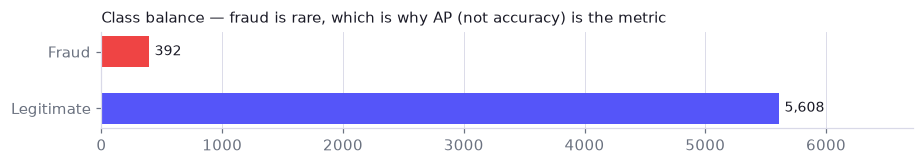

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 1.6))
ax.barh(["Legitimate"], [len(df) - n_fraud], color=BLUE, height=0.55)
ax.barh(["Fraud"], [n_fraud], color=FRAUD_RED, height=0.55)
ax.set_title("Class balance — fraud is rare, which is why AP (not accuracy) is the metric",
             loc="left", fontsize=10)
for yy, v in zip([0, 1], [len(df) - n_fraud, n_fraud]):
    ax.text(v + len(df) * 0.008, yy, f"{v:,}", va="center", fontsize=9, color=INK)
ax.set_xlim(0, len(df) * 1.12)
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

## 2 · Tokenize → foundation-model embeddings

This is the step that separates the paradigms. The decoder **Transaction Foundation
Model** treats a transaction like a language model treats a sentence: each field becomes
tokens (amount buckets, hashed merchants, temporal encodings — `src/tokenizer.py`), the
decoder runs a forward pass over the sequence, and the **last token's hidden state** is
kept as a **512-dimensional embedding** of the transaction.

Illustrative token strip for one (synthetic) fraud transaction:


In [5]:
row = df.iloc[int(np.argmax(y))]
tokens = ["<bos>",
          f"AMT_{int(np.log1p(row['Amount']) * 2)}",
          f"MERCH_{abs(int(row['Merchant Name'])) % 2000}",       # hashed, like src/tokenizer
          f"MCC_{row['MCC']}", f"HOUR_{int(row['Hour'])}",
          f"CHIP_{str(row['Use Chip']).split()[0].upper()}",
          f"STATE_{row['Merchant State']}", "<eos>"]
print("  ".join(tokens))
print("\n(illustrative — the real strip comes from src/tokenizer.py's"
      " FinancialTabularTokenizer with merchant hashing + temporal encoding)")

<bos>  AMT_7  MERCH_314  MCC_5912  HOUR_17  CHIP_ONLINE  STATE_ONLINE  <eos>

(illustrative — the real strip comes from src/tokenizer.py's FinancialTabularTokenizer with merchant hashing + temporal encoding)


In [6]:
# Real embeddings need the decoder checkpoint + a GPU (tfm_demo/export.py::_embed_rows,
# cached under data/embeddings/<target>/<budget>/). Here we CONSTRUCT synthetic 512-d
# embeddings whose geometry mimics what the FM learns: the observable signals PLUS the
# hidden behavioral factor from section 1 — the stand-in for sequence context (spending
# rhythm, merchant history) that a single tabular row cannot carry. That hidden factor
# is exactly why the embedding head out-scores the raw head in the real system.
EMBED_DIM = 512
rng = np.random.default_rng(7)

signals = np.column_stack([
    np.log1p(latents["amount"]) - 3.6,
    latents["odd_hour"].astype(float),
    latents["online"].astype(float),
    latents["risky_mcc"].astype(float),
    latents["behav"],                       # ← the part raw columns can't see
])
proj = rng.normal(0, 1, (signals.shape[1], EMBED_DIM))
emb = signals @ proj + rng.normal(0, 2.2, (len(df), EMBED_DIM))

print(f"embeddings: {emb.shape}  (SYNTHETIC — illustrative geometry, not FM output)")

embeddings: (6000, 512)  (SYNTHETIC — illustrative geometry, not FM output)


## 3 · Compress with PCA (512 → 64)

512 dimensions is more than XGBoost needs and slower than the live scorer wants, so the
export fits a PCA and keeps the top **64 components** (`PCA_DIM` in `tfm_demo/config.py`).
The elbow below is the whole argument: most of the embedding's variance survives in a
fraction of the dimensions.


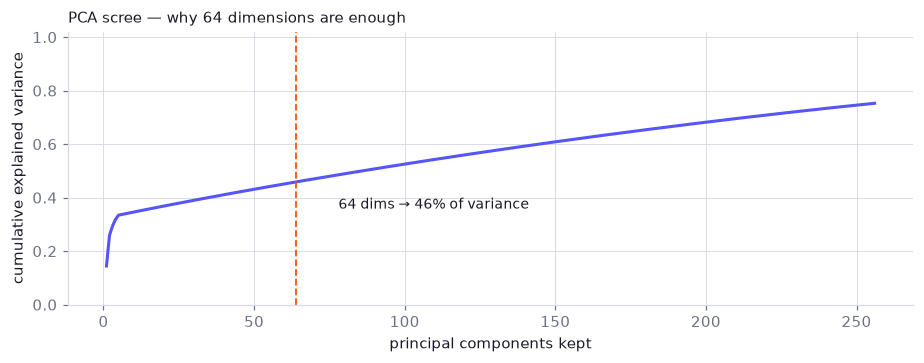

compressed: (6000, 64)


In [7]:
from sklearn.decomposition import PCA

# Fit on the (temporal) train slice only — the export does the same; fitting on
# everything would leak test-set structure into the transform.
i_fit = int(len(emb) * 0.70)
pca_full = PCA(n_components=min(256, EMBED_DIM), random_state=42).fit(emb[:i_fit])
evr = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(np.arange(1, len(evr) + 1), evr, color=BLUE, lw=2)
kept = evr[PCA_DIM - 1]
ax.axvline(PCA_DIM, color=ORANGE, lw=1.2, ls="--")
ax.annotate(f"{PCA_DIM} dims → {kept:.0%} of variance", (PCA_DIM, kept),
            xytext=(PCA_DIM + 14, kept - 0.10), fontsize=9, color=INK)
ax.set_xlabel("principal components kept"); ax.set_ylabel("cumulative explained variance")
ax.set_title("PCA scree — why 64 dimensions are enough", loc="left", fontsize=10)
ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()

pca = PCA(n_components=PCA_DIM, random_state=42).fit(emb[:i_fit])
emb_pca = pca.transform(emb)
print(f"compressed: {emb_pca.shape}")

## 4 · Train the three heads — with the progressive training budget

The same XGBoost classifier is trained three times; **only the inputs change**:

1. **Raw head** — the hand-picked tabular columns (classic ML baseline)
2. **Embedding head** — the 64 PCA components only
3. **Combined head** — raw columns ⊕ PCA components

### The training budget, in business terms

Training a model is a **purchasing decision**: you are buying model quality, and the
currency is **data volume and compute time**. The "training budget" is simply how much of
each a given run is allowed to spend:

- **Rows per split** — how much transaction history the foundation model reads and embeds.
  More history = more patterns seen = better fraud signal. This is the expensive part
  (GPU time scales with it).
- **Boosting rounds** — how long the classifier refines itself on that data. More rounds =
  a sharper decision boundary, with early-stopping so we never pay for rounds that stop
  helping.

In this demo, every run of *Build artifacts* is automatically granted a **larger budget
than the last** (`tfm_demo/runs.py`) — starting small and fast, plateauing at the full
budget. Three things make that pattern matter to the business, not just the lab:

1. **Spend is incremental and visible.** You don't bet a quarter's GPU budget on one big
   training job. Run #1 costs minutes and proves the pipeline; each later run buys a
   measured increment of quality. Every run's cost (rows, rounds, wall-clock duration) and
   its return (AUC / average precision on genuinely held-out, later-in-time transactions)
   are recorded side by side — a **cost-versus-quality curve you can audit**, not a claim.
2. **Improvement is causal, not cosmetic.** The dashboard's rising curve moves because the
   model really retrained on really more data — the same mechanism you'd use in
   production when new transaction history accrues. If a bigger budget ever stopped
   paying for itself, the flat curve would say so honestly — that is exactly the signal a
   budget owner needs to stop spending.
3. **The loop has no re-platforming tax.** Data, GPUs, training, versioning, and serving
   live on one governed platform, so "spend a bit more and retrain" is a button press, not
   a cross-team project. The marginal cost of the next quality increment is GPU-minutes —
   not integration work.

The chart below is the budget schedule itself — what each successive run is allowed to
spend. Section 6 then shows what that spend bought, run by run.


The app's NEXT run would be granted: 4,000 rows/split · 35% of full boosting rounds (tier 1)


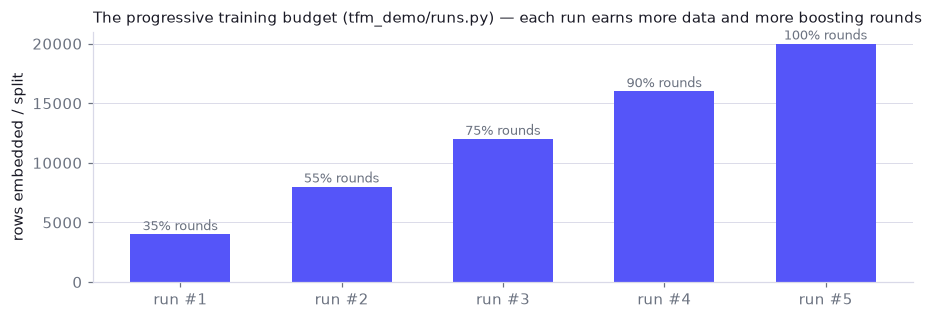

In [8]:
from tfm_demo import runs

budget = runs.next_budget()
sched = runs.schedule()
print(f"The app's NEXT run would be granted: {budget['embed_max']:,} rows/split · "
      f"{budget['xgb_scale']:.0%} of full boosting rounds (tier {budget['tier'] + 1})")

fig, ax = plt.subplots(figsize=(8.5, 3))
tiers = [f"run #{i + 1}" for i in range(len(sched))]
bars = ax.bar(tiers, [b["embed_max"] for b in sched], color=BLUE, width=0.62)
for b, s in zip(bars, sched):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 350,
            f"{s['xgb_scale']:.0%} rounds", ha="center", fontsize=8.5, color=MUTED)
ax.set_ylabel("rows embedded / split")
ax.set_title("The progressive training budget (tfm_demo/runs.py) — each run earns more "
             "data and more boosting rounds", loc="left", fontsize=10)
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

In [9]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve
import xgboost as xgb

# Temporal split by row order (mirrors the real temporal splits): 70 / 15 / 15.
n = len(df)
i_tr, i_va = int(n * 0.70), int(n * 0.85)
sl_tr, sl_va, sl_te = slice(0, i_tr), slice(i_tr, i_va), slice(i_va, n)
y_tr, y_va, y_te = y[sl_tr], y[sl_va], y[sl_te]

# Same preprocessor construction as tfm_demo/export.py.
preproc = make_column_transformer(
    (OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
     make_column_selector(dtype_include=["object", "category"])),
    remainder="passthrough",
)
X_raw = preproc.fit_transform(df.iloc[sl_tr])
inputs = {
    "raw":      (X_raw, preproc.transform(df.iloc[sl_va]), preproc.transform(df.iloc[sl_te])),
    "embed":    (emb_pca[sl_tr], emb_pca[sl_va], emb_pca[sl_te]),
}
inputs["combined"] = tuple(np.hstack(p) for p in zip(inputs["raw"], inputs["embed"]))

# Notebook-sized hyperparameters, scaled by the budget exactly like export._scaled().
scale = budget["xgb_scale"]
results = {}
for key, (Xt, Xv, Xte) in inputs.items():
    clf = xgb.XGBClassifier(
        n_estimators=max(60, round(220 * scale)), max_depth=6, learning_rate=0.08,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        eval_metric="auc", early_stopping_rounds=20, tree_method="hist",
    )
    clf.fit(Xt, y_tr, eval_set=[(Xv, y_va)], verbose=False)
    p = clf.predict_proba(Xte)[:, 1]
    results[key] = {"proba": p, "auc": roc_auc_score(y_te, p),
                    "ap": average_precision_score(y_te, p)}

table = pd.DataFrame({HEAD_LABELS[k]: {"test ROC-AUC": round(v["auc"], 4),
                                       "test avg precision": round(v["ap"], 4)}
                      for k, v in results.items()}).T
table["AP lift vs raw"] = [f"{(results[k]['ap'] - results['raw']['ap']) / results['raw']['ap']:+.1%}"
                           if k != "raw" else "—" for k in results]
table

,test ROC-AUC,test avg precision,AP lift vs raw
Raw tabular,0.5982,0.0904,—
FM embeddings,0.8302,0.2795,+209.2%
Combined,0.8319,0.2972,+228.8%


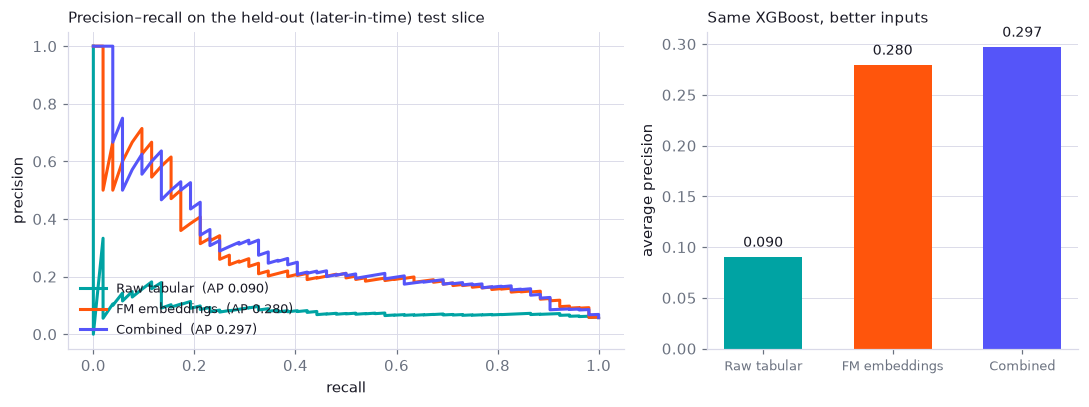

The story in one line: identical classifier, identical labels — the only change is
the representation, and the foundation-model embedding carries signal the raw
columns don't have.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={"width_ratios": [3, 2]})

# Precision-recall — the curve that matters at a 3-4% fraud rate.
ax = axes[0]
for k, r in results.items():
    prec, rec, _ = precision_recall_curve(y_te, r["proba"])
    ax.plot(rec, prec, color=HEAD_COLORS[k], lw=2,
            label=f"{HEAD_LABELS[k]}  (AP {r['ap']:.3f})")
ax.set_xlabel("recall"); ax.set_ylabel("precision")
ax.set_title("Precision–recall on the held-out (later-in-time) test slice",
             loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8.5, loc="lower left")

# AP per head with the lift called out.
ax = axes[1]
keys = list(results)
bars = ax.bar([HEAD_LABELS[k] for k in keys], [results[k]["ap"] for k in keys],
              color=[HEAD_COLORS[k] for k in keys], width=0.6)
for b, k in zip(bars, keys):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
            f"{results[k]['ap']:.3f}", ha="center", fontsize=9, color=INK)
ax.set_ylabel("average precision")
ax.set_title("Same XGBoost, better inputs", loc="left", fontsize=10)
ax.grid(axis="x", visible=False)
ax.tick_params(axis="x", labelsize=8.5)
plt.tight_layout(); plt.show()

print("The story in one line: identical classifier, identical labels — the only change is\n"
      "the representation, and the foundation-model embedding carries signal the raw\n"
      "columns don't have.")

## 5 · The embedding map

The app's embedding map is a **UMAP projection of the test-set embeddings** (cuML UMAP on
the GPU; the live scorer projects each new transaction into the *same* fitted space, which
is why the orange dot lands meaningfully). Without a GPU we project the first two PCA
components instead — same idea, cheaper geometry: fraud clusters without ever seeing a
label.


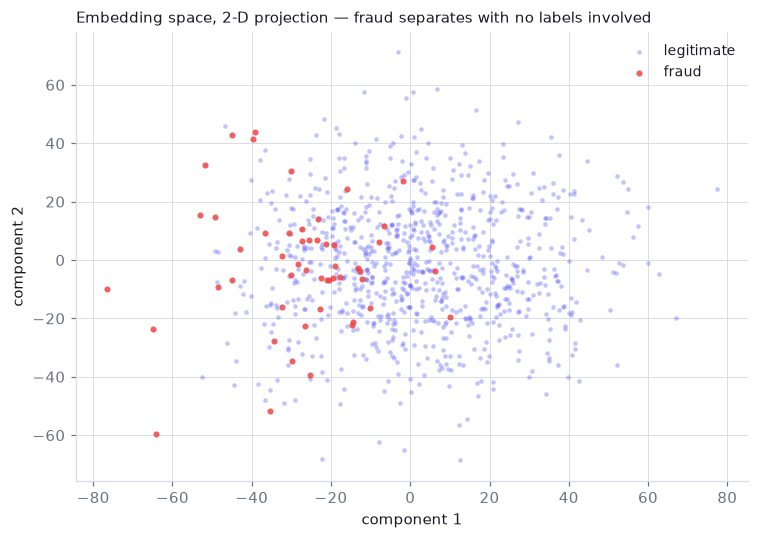

In [11]:
proj2 = emb_pca[sl_te][:, :2]
fig, ax = plt.subplots(figsize=(7, 5))
mask = y_te.astype(bool)
ax.scatter(*proj2[~mask].T, s=9, c=BLUE, alpha=0.35, lw=0, label="legitimate")
ax.scatter(*proj2[mask].T, s=16, c=FRAUD_RED, alpha=0.85, lw=0, label="fraud")
ax.set_xlabel("component 1"); ax.set_ylabel("component 2")
ax.set_title("Embedding space, 2-D projection — fraud separates with no labels involved",
             loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 6 · Improvement over time — the run history

Every successful export appends a record to `.runs_history.json` (`tfm_demo/runs.py`):
budget, per-head test AUC/AP, duration, and later the Model Registry version. The **Model
Lifecycle** tab charts this live; the cell below reads the same file, so on a machine
where the app has trained, this plot shows **your real runs**.

Read it as the other half of the budget schedule from section 4: that chart showed what
each run was *allowed to spend*; this one shows what the spend *bought* — the
cost-versus-quality curve a model owner reports against, with green rings marking the runs
promoted to the Model Registry.


In [12]:
hist = runs.history()
if not hist:
    print("No training runs recorded here yet — run 'Build artifacts' in the app (or\n"
          "export_for_demo.py on the GPU box) and re-run this cell to see real history.")
else:
    rows = []
    for r in hist:
        for m in r["models"]:
            if m["key"] in HEAD_COLORS:
                rows.append({"run": r["run"], "head": m["key"], "ap": m["test_ap"],
                             "registered": r["registry"]["registered"]})
    h = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(8.5, 3.8))
    for k in ["raw", "embed", "combined"]:
        s = h[h["head"] == k]
        if len(s):
            ax.plot(s["run"], s["ap"], color=HEAD_COLORS[k], lw=2, marker="o",
                    ms=4, label=HEAD_LABELS[k])
    reg = h[(h["head"] == "combined") & h["registered"]]
    if len(reg):
        ax.scatter(reg["run"], reg["ap"], s=130, facecolors="none",
                   edgecolors="#10b981", lw=1.6, zorder=5, label="registered version")
    ax.set_xlabel("training run"); ax.set_ylabel("test avg precision")
    ax.set_xticks(sorted(h["run"].unique()))
    ax.set_title("Recorded runs — real metrics from .runs_history.json",
                 loc="left", fontsize=10)
    ax.legend(frameon=False, fontsize=8.5)
    plt.tight_layout(); plt.show()

No training runs recorded here yet — run 'Build artifacts' in the app (or
export_for_demo.py on the GPU box) and re-run this cell to see real history.


## 7 · Register & deploy — where Cloudera turns a notebook into an operating model

Everything above is standard data science. What the platform adds is that **each stage is a
governed, one-click primitive** instead of glue code:

| Pipeline stage | Cloudera AI primitive | In this repo |
|---|---|---|
| Data prep & storage | Data connections · Jobs | `pipelines/prepare_data.py`, `tfm_demo/storage.py` |
| Training (this notebook's stages 2–5) | GPU workloads, in-app job | `tfm_demo/export.py`, `tfm_demo/jobs.py` |
| Versioning | **Model Registry** (MLflow-backed) | `tfm_demo/registry.py` |
| Serving | **Model endpoint** (build + deploy, own resources/auth) | `tfm_demo/registry.py`, `tfm_demo/registry_predict.py` |
| The demo app itself | **Application** | `app/serve_app.py` |
| Reproducing all of it | **AMP manifest** — one click, any workspace | `.project-metadata.yaml` |

The registry probe below goes green inside a CML workload (APIv2 key injected
automatically); anywhere else it explains why it can't — the same honest degradation the
app's registry panel shows.


In [13]:
from tfm_demo import registry

ok, reason = registry.available()
print(f"Model Registry available here: {ok}" + (f" — {reason}" if reason else ""))
if ok:
    status = registry.status()
    print(f"Registered model: {status['model_name']}")
    for v in status["versions"][:5]:
        print(f"  v{v['version']}  ({v['created_at']})")
    if not status["versions"]:
        print("  no versions yet — press 'Register latest run' on the Model Lifecycle tab")

Model Registry available here: False — not running on Cloudera AI (no CML workload environment)


On Cloudera AI, registration is one call — the tracking server *is* the registry, so
this creates the model on first use and a new version every run after (this is what the
dashboard's **Register latest run** button executes, via `tfm_demo/registry.py`):

```python
import mlflow

mlflow.set_experiment("tfm-fraud-demo")
with mlflow.start_run(run_name=run_id):
    mlflow.log_params(budget)
    mlflow.log_metric("combined_test_ap", results["combined"]["ap"])
    mlflow.pyfunc.log_model(
        artifact_path="model",
        python_model=CombinedHeadModel(),           # wraps head + preprocessor + PCA
        artifacts={"xgb_combined": "demo_artifacts/xgb_combined.joblib",
                   "preprocessor": "demo_artifacts/preprocessor.joblib",
                   "pca": "demo_artifacts/pca.joblib"},
        registered_model_name="tfm-fraud-combined", # ← new registry version, every run
    )
```

…and `cmlapi` then builds + deploys that registered version as a REST endpoint with its
own resources and auth (`registry.deploy_latest`).

## Takeaways

- **One classifier, three representations** — the AUC/AP gap between the raw and
  embedding heads is the measurable value of the foundation model, recomputed on the real
  test slice at every training run.
- **The loop is the product**: train → record → register → deploy → observe, and every
  arrow in that loop is a platform primitive, not a script someone maintains.
- **Data never moves.** Splits stay in governed storage, embeddings and models stay in the
  project, the endpoint serves inside the same security perimeter, and the entire stack —
  including this notebook — redeploys from one AMP manifest.

*Next steps: open the app's **Model Lifecycle** tab to watch the pipeline you just walked
through animate live, or read `docs/demo-script.md` for the presenter version of this
story.*
